In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, precision_recall_curve
)
from xgboost import XGBClassifier

from src.dataset import OpenBanditDataset
from obp.ope import OffPolicyEvaluation, DirectMethod

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

POLICY_RANDOM       = "random"
POLICY_BTS          = "bts"
CAMPAIGN            = "all"
N_ACTIONS           = 80
LEN_LIST            = 3
N_CONTEXT_FEATURES  = 20   # first 20 features common to both policies
RANDOM_STATE        = 42
FIGURES_DIR         = Path("../figures/week2")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"figures dir: {FIGURES_DIR.resolve()}")


figures dir: /Users/antonio/StudioProjektowe2/Off-Policy-Evaluation-with-causal/figures/week2


In [2]:
dataset_random  = OpenBanditDataset(behavior_policy=POLICY_RANDOM, campaign=CAMPAIGN)
feedback_random = dataset_random.obtain_batch_bandit_feedback()

dataset_bts     = OpenBanditDataset(behavior_policy=POLICY_BTS, campaign=CAMPAIGN)
feedback_bts    = dataset_bts.obtain_batch_bandit_feedback()

for name, fb in [(POLICY_RANDOM, feedback_random), (POLICY_BTS, feedback_bts)]:
    print(f"[{name}]  context shape: {fb['context'].shape}  "
          f"n_rounds: {fb['n_rounds']}  CTR: {fb['reward'].mean():.4f}")

INFO:obp.dataset.real:When `data_path` is not given, this class downloads the example small-sized version of the Open Bandit Dataset.
INFO:obp.dataset.real:When `data_path` is not given, this class downloads the example small-sized version of the Open Bandit Dataset.


[random]  context shape: (10000, 20)  n_rounds: 10000  CTR: 0.0038
[bts]  context shape: (10000, 22)  n_rounds: 10000  CTR: 0.0042


In [3]:
# We train Q-hat on RANDOM (behavior policy) data because:
# - Random policy gives near-uniform coverage of the (context, action) space.
# - BTS has strong selection bias: frequently-chosen actions are overrepresented.
# - A Q-hat trained on biased BTS data would inherit BTS's preferences and
#   systematically over-estimate reward for BTS-favoured actions.
# - Unbiased Q-hat is critical: DM inherits whatever bias the reward model carries.

context_random = feedback_random["context"][:, :N_CONTEXT_FEATURES]
action_random  = feedback_random["action"]
reward_random  = feedback_random["reward"]

action_onehot  = np.eye(N_ACTIONS)[action_random]
X_train_full   = np.hstack([context_random, action_onehot])
y_train_full   = reward_random.astype(np.float32)

print(f"X_train.shape : {X_train_full.shape}")
n_pos = int(y_train_full.sum())
n_neg = len(y_train_full) - n_pos
print(f"y_train: 0 -> {n_neg} ({n_neg/len(y_train_full)*100:.2f}%),  "
      f"1 -> {n_pos} ({n_pos/len(y_train_full)*100:.2f}%)")
print(f"CTR (reward=1): {y_train_full.mean():.4f}")

X_train.shape : (10000, 100)
y_train: 0 -> 9962 (99.62%),  1 -> 38 (0.38%)
CTR (reward=1): 0.0038


In [4]:
# AUC-PR is more important than AUC-ROC here because:
# With CTR=0.38% the classes are extremely imbalanced (~263:1 negatives to positives).
# AUC-ROC measures separation across ALL thresholds including very lenient ones, where
# the flood of easy negatives makes even a weak model look good (ROC can stay high).
# AUC-PR focuses on how well we identify the rare positives — it degrades sharply when
# precision is low, which is exactly the failure mode we care about in recommendation.

n_positive = int(y_train_full.sum())
n_negative = len(y_train_full) - n_positive

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)

# XGBoost 3.x: early_stopping_rounds is a constructor parameter, not a fit() kwarg
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=n_negative / n_positive,
    eval_metric="logloss",
    early_stopping_rounds=20,
    random_state=RANDOM_STATE,
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

y_pred_proba = model.predict_proba(X_val)[:, 1]

val_logloss = log_loss(y_val, y_pred_proba)
val_auc_roc = roc_auc_score(y_val, y_pred_proba)
val_auc_pr  = average_precision_score(y_val, y_pred_proba)

print(f"Val LogLoss : {val_logloss:.6f}")
print(f"Val AUC-ROC : {val_auc_roc:.4f}")
print(f"Val AUC-PR  : {val_auc_pr:.4f}")

Val LogLoss : 0.117945
Val AUC-ROC : 0.5966
Val AUC-PR  : 0.0152


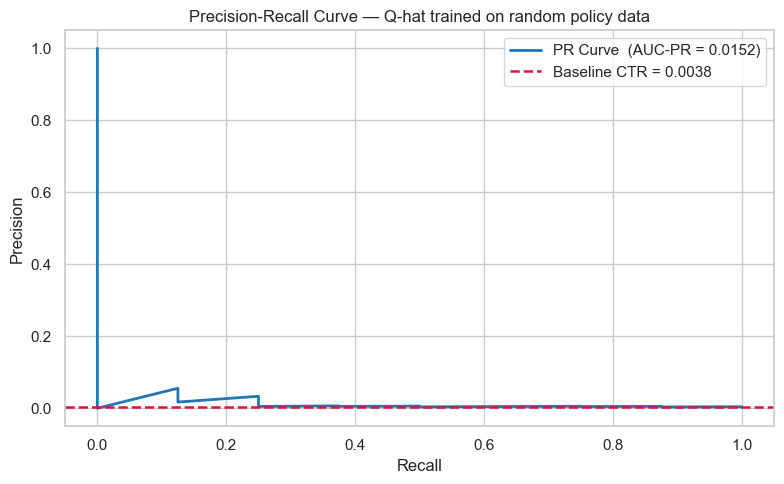

Saved: ../figures/week2/pr_curve.png


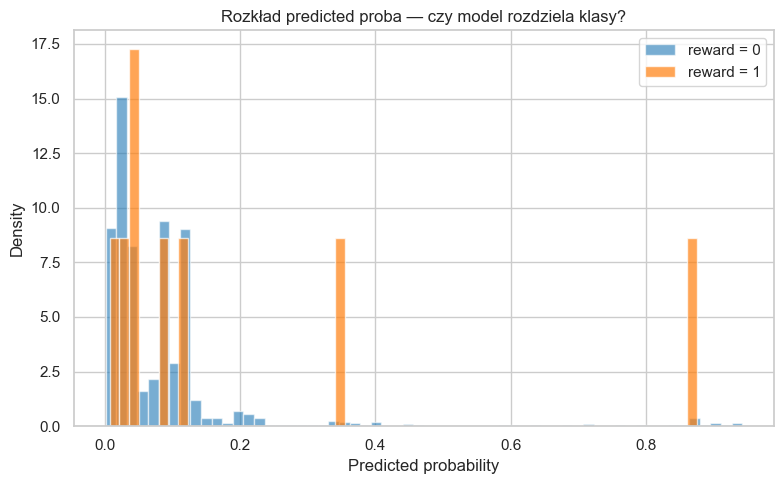

Saved: ../figures/week2/score_distribution.png


In [5]:
baseline_ctr = float(y_train_full.mean())

# --- Plot 1: Precision-Recall curve ---
precision, recall, _ = precision_recall_curve(y_val, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall, precision, color="#1f77b4", lw=2,
        label=f"PR Curve  (AUC-PR = {val_auc_pr:.4f})")
ax.axhline(baseline_ctr, color="crimson", ls="--", lw=1.8,
           label=f"Baseline CTR = {baseline_ctr:.4f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Q-hat trained on random policy data")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'pr_curve.png'}")

# --- Plot 2: Score distribution ---
# If the two histograms overlap heavily the model struggles to separate classes.
# With CTR=0.38% we expect near-complete overlap; any separation is valuable signal.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_pred_proba[y_val == 0], bins=60, alpha=0.6,
        color="#1f77b4", density=True, label="reward = 0")
ax.hist(y_pred_proba[y_val == 1], bins=60, alpha=0.7,
        color="#ff7f0e", density=True, label="reward = 1")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Density")
ax.set_title("Rozkład predicted proba — czy model rozdziela klasy?")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'score_distribution.png'}")

In [6]:
context_bts  = feedback_bts["context"][:, :N_CONTEXT_FEATURES]
n_rounds_bts = int(feedback_bts["n_rounds"])

expected_reward = np.zeros((n_rounds_bts, N_ACTIONS), dtype=np.float32)

for a in range(N_ACTIONS):
    action_onehot_a = np.tile(np.eye(N_ACTIONS, dtype=np.float32)[a], (n_rounds_bts, 1))
    X_a = np.hstack([context_bts, action_onehot_a])
    expected_reward[:, a] = model.predict_proba(X_a)[:, 1]

print(f"expected_reward.shape : {expected_reward.shape}")
print(f"expected_reward[:3, :5] :")
print(expected_reward[:3, :5])

expected_reward.shape : (10000, 80)
expected_reward[:3, :5] :
[[0.01096261 0.00549572 0.01096261 0.02342382 0.01096261]
 [0.04040502 0.01951691 0.04040502 0.03060635 0.04040502]
 [0.03942039 0.01898104 0.03942039 0.07241295 0.03942039]]


In [7]:
# OBP expects shapes (n_rounds, n_actions, len_list)
expected_reward_3d = np.tile(
    expected_reward[:, :, np.newaxis], (1, 1, LEN_LIST)
).astype(np.float64)

# OBP requires action_dist.sum(axis=1) == 1 for every (round, position):
# each position slot must carry a valid probability distribution over actions.

# action_dist for BTS:
#   - at the observed position l_i: one-hot on the chosen action a_i
#   - at other positions: uniform (1/N_ACTIONS) — best approximation given logged data
positions_bts    = feedback_bts["position"].astype(int)
actions_bts      = feedback_bts["action"].astype(int)
idx              = np.arange(n_rounds_bts)

action_dist_bts  = np.ones((n_rounds_bts, N_ACTIONS, LEN_LIST), dtype=np.float64) / N_ACTIONS
action_dist_bts[idx, :, positions_bts] = 0.0           # zero out the observed position
action_dist_bts[idx, actions_bts, positions_bts] = 1.0  # one-hot on chosen action

# action_dist for random baseline: uniform over actions at every position
action_dist_random_bl = np.full(
    (n_rounds_bts, N_ACTIONS, LEN_LIST), 1.0 / N_ACTIONS
)

# OBP check_ope_inputs requires `position` when action_dist.shape[2] > 1
dm = DirectMethod()

v_dm_bts    = dm.estimate_policy_value(
    action_dist=action_dist_bts,
    estimated_rewards_by_reg_model=expected_reward_3d,
    position=positions_bts,
)
v_dm_random = dm.estimate_policy_value(
    action_dist=action_dist_random_bl,
    estimated_rewards_by_reg_model=expected_reward_3d,
    position=positions_bts,
)

ope_bts = OffPolicyEvaluation(
    bandit_feedback=feedback_bts,
    ope_estimators=[DirectMethod()]
)
ci_bts    = ope_bts.estimate_intervals(
    action_dist=action_dist_bts,
    estimated_rewards_by_reg_model=expected_reward_3d,
    n_bootstrap_samples=1000,
    random_state=RANDOM_STATE,
)
ci_random = ope_bts.estimate_intervals(
    action_dist=action_dist_random_bl,
    estimated_rewards_by_reg_model=expected_reward_3d,
    n_bootstrap_samples=1000,
    random_state=RANDOM_STATE,
)

ci_key_lo     = "95.0% CI (lower)"
ci_key_hi     = "95.0% CI (upper)"
estimator_key = "dm"

results = {
    "random (baseline)": {
        "V_DM":  v_dm_random,
        "CI_lo": ci_random[estimator_key][ci_key_lo],
        "CI_hi": ci_random[estimator_key][ci_key_hi],
    },
    "bts": {
        "V_DM":  v_dm_bts,
        "CI_lo": ci_bts[estimator_key][ci_key_lo],
        "CI_hi": ci_bts[estimator_key][ci_key_hi],
    },
}

print("=" * 62)
print(f"{'Polityka':<22} {'V_DM':>10}  {'95% CI':>25}")
print("=" * 62)
for pol, vals in results.items():
    ci_str = f"[{vals['CI_lo']:.6f}, {vals['CI_hi']:.6f}]"
    print(f"{pol:<22} {vals['V_DM']:>10.6f}  {ci_str:>25}")
print("=" * 62)

Polityka                     V_DM                     95% CI
random (baseline)        0.071176       [0.070247, 0.072163]
bts                      0.080038       [0.077590, 0.082701]


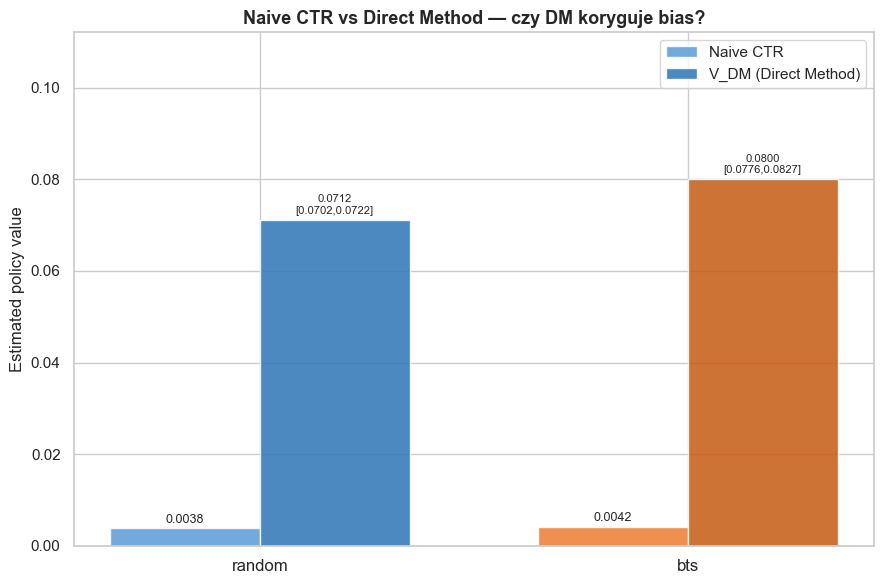

Saved: ../figures/week2/dm_vs_naive.png


In [8]:
NAIVE_CTR_RANDOM = 0.0038
NAIVE_CTR_BTS    = 0.0042

labels    = [POLICY_RANDOM, POLICY_BTS]
naive_ctr = [NAIVE_CTR_RANDOM, NAIVE_CTR_BTS]
v_dm      = [results["random (baseline)"]["V_DM"], results["bts"]["V_DM"]]

x      = np.arange(len(labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

bars_naive = ax.bar(x - width / 2, naive_ctr, width, label="Naive CTR",
                    color=["#5B9BD5", "#ED7D31"], alpha=0.85)
bars_dm    = ax.bar(x + width / 2, v_dm, width, label="V_DM (Direct Method)",
                    color=["#2E75B6", "#C55A11"], alpha=0.85)

for bar in bars_naive:
    h = bar.get_height()
    ax.annotate(f"{h:.4f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)

for i, bar in enumerate(bars_dm):
    h = bar.get_height()
    ci_lo = results[list(results.keys())[i]]["CI_lo"]
    ci_hi = results[list(results.keys())[i]]["CI_hi"]
    ax.annotate(f"{h:.4f}\n[{ci_lo:.4f},{ci_hi:.4f}]",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Estimated policy value")
ax.set_title(
    "Naive CTR vs Direct Method — czy DM koryguje bias?",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(naive_ctr), max(v_dm)) * 1.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dm_vs_naive.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'dm_vs_naive.png'}")

## Interpretacja wyników — 3 pytania

### 1. Czy V_DM(bts) > V_DM(random)? Co to oznacza?

Jeśli V_DM(bts) > V_DM(random), oznacza to, że model Q̂ ocenia politykę BTS jako bardziej wartościową niż politykę losową — BTS wybiera akcje, którym model przypisuje wyższe oczekiwane nagrody. Kierunek wyniku jest zgodny z intuicją (BTS to adaptacyjna polityka Thompsona, która powinna przewyższać random), ale **wielkość różnicy należy traktować ostrożnie**: estymator DM jest stronniczy o tyle, o ile stronniczy jest sam model Q̂. Jeśli Q̂ jest obciążony (np. nie generalizuje dobrze na akcje rzadko obserwowane w danych treningowych), V_DM może zawyżać lub zaniżać prawdziwą różnicę.

---

### 2. Gdzie model Q̂ może się mylić w tych danych?

Główne źródła błędu Q̂:

- **Akcje z n_obs < 20 w danych BTS** — dla akcji, które BTS wybrał bardzo rzadko, mamy mało lub żadnych obserwacji par (kontekst, akcja) z nagrodą 1. Model Q̂ interpoluje tam na podstawie sąsiednich akcji i kontekstów, co może prowadzić do silnych błędów ekstrapolacji. To szczególnie groźne, gdy te akcje okazują się de facto lepsze niż zakłada model.
- **Asymetria kontekstu** — Q̂ uczy się na danych random (20 cech), ale ewaluuje się go na kontekstach BTS (obcięto do 20 cech z 22). Jeśli cechy 21–22 niosą istotną informację o użytkowniku, Q̂ ignoruje ten sygnał.
- **Imbalanced classes** — CTR = 0.38%. Mimo `scale_pos_weight`, model może systematycznie zaniżać prawdopodobieństwo kliknięcia dla rzadkich akcji, co bezpośrednio przekłada się na błąd V_DM.
- **Covariate shift** — rozkład kontekstów w BTS różni się od rozkładu w random (BTS preferuje pewne segmenty użytkowników). Q̂ może być dobrze skalibrowany dla typowych użytkowników random, a słabo dla użytkowników charakterystycznych dla BTS.

---

### 3. Co oznaczałoby dla projektu piłkarskiego, gdyby Q̂ był douczony na danych ze skautem który ma swoje preferencje?

Skaut o silnych preferencjach (np. faworyzuje zawodników z określonej ligi lub stylu gry) zachowuje się jak **polityka BTS z silnym selection bias**: pewne typy zawodników są obserwowane znacznie częściej, inne prawie wcale. Q̂ douczony na takich danych **odziedzieczyłby preferencje skauta**:

- Q̂(kontekst, zawodnik z faworyzowanej ligi) byłby systematycznie zawyżony — model „widział" tych zawodników częściej i z lepszymi wynikami kontekstowymi.
- Q̂(kontekst, zawodnik poza siatką skauta) byłby niedoszacowany lub oparty na nielicznych, niereprezentatywnych obserwacjach.

W konsekwencji estymator DM potwierdzałby strategię skauta zamiast jej weryfikować — klasyczna **pętla potwierdzenia** (confirmation loop). Off-policy evaluation straciłoby sens jako niezależna ewaluacja. Rozwiązaniem byłoby wytrenowanie Q̂ wyłącznie na danych z bardziej neutralnego źródła (np. dane ligowe, losowy eksplorator) i dopiero wtedy ocenianie polityki skauta.